# Import Library

In [295]:
!pip install google_play_scraper

In [296]:
!pip install gensim

In [297]:
from google_play_scraper import reviews, Sort
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from collections import Counter
import re
from sklearn.metrics import classification_report
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import numpy as np
from sklearn.metrics import f1_score
from nltk.corpus import wordnet
import gensim
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.utils.class_weight import compute_class_weight

from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.initializers import Constant
from tensorflow.keras.layers import Dense, Embedding, Activation, Flatten

from tensorflow.keras.callbacks import EarlyStopping


# Web Scrapping

In [298]:
# Documentation : https://pypi.org/project/google-play-scraper/

In [299]:
result, continuation_token = reviews(
    'com.ea.game.pvzfree_row',
    lang='en',
    country='us',
    sort=Sort.NEWEST,
    count=2000,
)

In [300]:
df = pd.DataFrame(result)

In [301]:
df.head(5)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1cdea09e-05a8-4657-9a5f-35d4679df623,Cristeta Barot,https://play-lh.googleusercontent.com/a/ACg8oc...,The close button of the ads that contain ads i...,1,0,3.15.0,2026-04-23 17:42:24,None,None,3.15.0
1,cdd49f91-15d0-4150-af79-f273a0c82695,Gggkkjj Gggdfh,https://play-lh.googleusercontent.com/a-/ALV-U...,grabe super amazing 5 ⭐⭐⭐⭐⭐ kasi dami yan naka...,5,0,3.15.0,2026-04-23 11:20:11,None,None,3.15.0
2,12145016-96c3-47cd-b822-fe74f8bea820,Ava Schuricht (1221),https://play-lh.googleusercontent.com/a-/ALV-U...,one of my favorite games ever,5,0,None,2026-04-23 09:48:30,None,None,None
3,31046d3e-dd38-4d53-80cc-890ee504003a,Elizabeth,https://play-lh.googleusercontent.com/a-/ALV-U...,Game doesn't load. Used to be a great game tha...,1,0,3.15.0,2026-04-23 09:47:29,None,None,3.15.0
4,8e5ba7d3-1553-4377-b5ac-beb706a6f3e5,Mohamed Othman,https://play-lh.googleusercontent.com/a/ACg8oc...,nice but mushroom and aquatic gardens need a w...,4,0,3.15.0,2026-04-23 06:49:46,None,None,3.15.0


In [302]:
df = df[['content', 'score']]

In [303]:
df.head(5)

,content,score
0,The close button of the ads that contain ads i...,1
1,grabe super amazing 5 ⭐⭐⭐⭐⭐ kasi dami yan naka...,5
2,one of my favorite games ever,5
3,Game doesn't load. Used to be a great game tha...,1
4,nice but mushroom and aquatic gardens need a w...,4


In [304]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  2000 non-null   object
 1   score    2000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


# EDA

In [305]:
df.isnull().sum()

,0
content,0
score,0


In [306]:
df.duplicated(subset=['content', 'score']).sum()

np.int64(112)

In [307]:
df = df.drop_duplicates(subset=['content', 'score'])

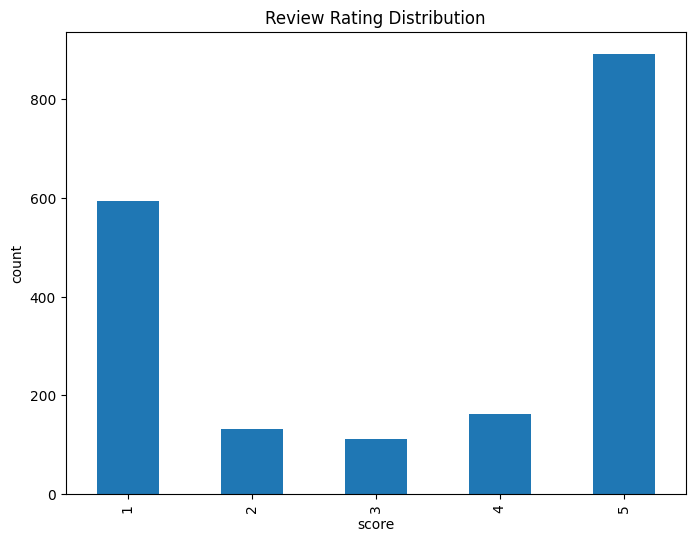

In [308]:
plt.figure(figsize=(8, 6))

df['score'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('score')
plt.ylabel('count')
plt.title('Review Rating Distribution')
plt.show()

In [309]:
df['score'].value_counts()

,count
score,
5,892
1,593
4,161
2,131
3,111


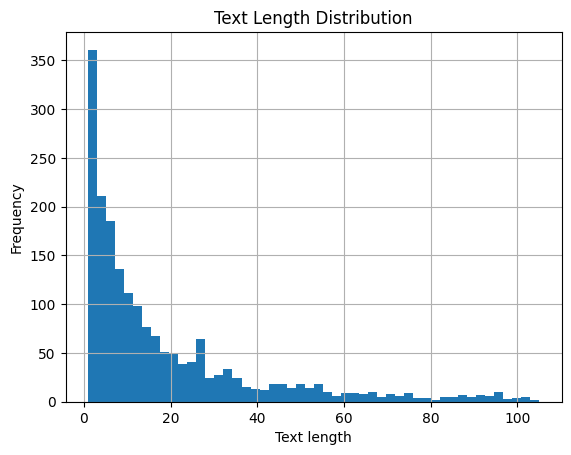

In [310]:
df['text_length'] = df['content'].apply(lambda x : len(x.split()))

df['text_length'].hist(bins=50)
plt.xlabel('Text length')
plt.ylabel('Frequency')
plt.title('Text Length Distribution')
plt.show()

In [311]:
all_words = " ".join(df['content']).split()
word_freq = Counter(all_words)

word_freq.most_common(20)

[('the', 1350),
 ('game', 1079),
 ('I', 907),
 ('and', 885),
 ('to', 885),
 ('it', 692),
 ('this', 625),
 ('a', 605),
 ('is', 587),
 ('but', 431),
 ('of', 399),
 ('you', 383),
 ('ads', 324),
 ('for', 302),
 ('so', 287),
 ('my', 270),
 ('play', 259),
 ('have', 230),
 ('in', 225),
 ('good', 224)]

In [312]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

In [313]:
df['clean_content'] = df['content'].apply(clean_text)

In [314]:
all_words = " ".join(df['clean_content']).split()
word_freq = Counter(all_words)

word_freq.most_common(20)

[('the', 1449),
 ('game', 1364),
 ('i', 1110),
 ('and', 926),
 ('to', 897),
 ('it', 844),
 ('this', 745),
 ('a', 629),
 ('is', 610),
 ('ads', 511),
 ('but', 471),
 ('you', 421),
 ('of', 406),
 ('its', 335),
 ('for', 320),
 ('so', 315),
 ('play', 302),
 ('my', 287),
 ('good', 269),
 ('in', 243)]

In [315]:
def get_top_words(text_series, n=30):
    words = ' '.join(text_series).split()
    return Counter(words).most_common(n)

In [316]:
top_words_1 = get_top_words(df[df['score']==1]['clean_content'])
top_words_2 = get_top_words(df[df['score']==2]['clean_content'])
top_words_3 = get_top_words(df[df['score']==3]['clean_content'])
top_words_4 = get_top_words(df[df['score']==4]['clean_content'])
top_words_5 = get_top_words(df[df['score']==5]['clean_content'])

print("Rating 1:", top_words_1)
print("Rating 2:", top_words_2)
print("Rating 3:", top_words_3)
print("Rating 4:", top_words_4)
print("Rating 5:", top_words_5)

Rating 1: [('the', 555), ('to', 415), ('game', 390), ('i', 353), ('and', 316), ('ads', 301), ('it', 266), ('a', 235), ('this', 228), ('you', 183), ('of', 169), ('is', 156), ('for', 147), ('but', 133), ('play', 130), ('ad', 125), ('on', 113), ('have', 110), ('get', 96), ('so', 95), ('my', 95), ('just', 94), ('not', 92), ('in', 89), ('no', 88), ('even', 81), ('an', 80), ('its', 80), ('that', 79), ('after', 78)]
Rating 2: [('the', 155), ('to', 123), ('game', 103), ('i', 94), ('and', 88), ('it', 88), ('ads', 78), ('a', 62), ('this', 60), ('you', 55), ('of', 45), ('is', 44), ('but', 43), ('for', 42), ('get', 35), ('ad', 34), ('its', 32), ('have', 29), ('my', 26), ('so', 26), ('an', 25), ('that', 25), ('in', 25), ('play', 24), ('on', 24), ('many', 22), ('now', 21), ('no', 21), ('watch', 20), ('with', 20)]
Rating 3: [('the', 186), ('game', 124), ('i', 113), ('and', 109), ('to', 103), ('it', 96), ('but', 65), ('a', 63), ('is', 53), ('this', 51), ('of', 44), ('ads', 42), ('its', 38), ('you', 37

Temuan 1 : Kondisi dataset ternyata banyak stopwords yang bisa menjadi noise untuk sentimen analysis dan perlu adanya stopwords removal



In [317]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [318]:
list_stopwords = set(stopwords.words('english'))

list_stopwords.discard('not')
list_stopwords.discard('no')
list_stopwords.discard('nor')


In [319]:
def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word not in list_stopwords]
    return ' '.join(filtered)

df['no_stopwords'] = df['clean_content'].apply(remove_stopwords)

In [320]:
top_words_1 = get_top_words(df[df['score']==1]['no_stopwords'])
top_words_2 = get_top_words(df[df['score']==2]['no_stopwords'])
top_words_3 = get_top_words(df[df['score']==3]['no_stopwords'])
top_words_4 = get_top_words(df[df['score']==4]['no_stopwords'])
top_words_5 = get_top_words(df[df['score']==5]['no_stopwords'])

print("Rating 1:", top_words_1)
print("Rating 2:", top_words_2)
print("Rating 3:", top_words_3)
print("Rating 4:", top_words_4)
print("Rating 5:", top_words_5)

Rating 1: [('game', 390), ('ads', 301), ('play', 130), ('ad', 125), ('not', 100), ('get', 96), ('no', 88), ('even', 81), ('loading', 77), ('dont', 62), ('screen', 58), ('watch', 58), ('cant', 57), ('version', 55), ('many', 54), ('ea', 47), ('doesnt', 42), ('time', 41), ('level', 39), ('every', 39), ('ruined', 39), ('like', 37), ('used', 37), ('load', 36), ('past', 36), ('free', 35), ('app', 33), ('good', 33), ('wont', 31), ('pay', 31)]
Rating 2: [('game', 103), ('ads', 78), ('get', 35), ('ad', 34), ('play', 24), ('many', 22), ('no', 21), ('watch', 20), ('like', 19), ('new', 18), ('not', 17), ('got', 15), ('cant', 15), ('even', 14), ('loading', 14), ('used', 14), ('one', 14), ('playing', 14), ('version', 14), ('update', 14), ('good', 14), ('level', 13), ('lawn', 11), ('back', 11), ('endless', 10), ('love', 10), ('long', 10), ('load', 10), ('screen', 9), ('fun', 9)]
Rating 3: [('game', 124), ('ads', 42), ('good', 27), ('play', 23), ('get', 20), ('not', 17), ('update', 16), ('lawn', 14), 

Temuan 1 : Terdapat beberapa kata yang dominan khusu pada rating tertentu. Selain itu ada juga kata yang dominan di semua ratin. kKata seperti ini sebaiknya dihapus karena bisa menjadi noise dan tidak membantu dalam membedakan sentimen, seperti :
- game
- games
- play
- get
- one
- time
- many

Temuan 2 : Dibutuhkan Lematisasi untuk mengurangi token (lihat games dan ads)

Temuan 3 : Terdapat beberapa kata tidak standar seperti :
- pvz atau ea
- dont, doesnt, cant

sebaiknya dihandle

# Preprocessing

In [321]:
score_map = {
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    5: 4
}

df['score'] = df['score'].map(score_map)

In [322]:
stop_words = set(stopwords.words('english'))

stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('nor')

custom_word = {'game', 'games', 'play', 'get', 'one', 'time', 'many'}
stop_words = stop_words.union(custom_word)

In [323]:
def cleansing(df):
    df_clean = df.str.lower()

    df_clean = [re.sub(r'[^a-z\s]', '', i) for i in df_clean]

    df_clean = [i.replace("dont", "do not")
                  .replace("cant", "can not")
                  .replace("doesnt", "does not") for i in df_clean]

    df_clean = [re.sub(r'\s+', ' ', i).strip() for i in df_clean]

    return df_clean

In [324]:
def tokenize(df_clean):
    df_token = [word_tokenize(i) for i in df_clean]

    return df_token

In [325]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [326]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [327]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens_list):
    lemmatized = []
    for tokens in tokens_list:
        pos_tags = pos_tag(tokens)
        lemmatized.append([
            lemmatizer.lemmatize(word, get_wordnet_pos(pos))
            for word, pos in pos_tags
        ])
    return lemmatized

In [328]:
def remove_stopwords(tokens_list, stop_words):
    return [[w for w in words if w not in stop_words] for words in tokens_list]

In [329]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [330]:
clean = cleansing(df['content'])

tokens_raw = tokenize(clean)

tokens_lemmatized = lemmatize_tokens(tokens_raw)

tokens_final = remove_stopwords(tokens_lemmatized, stop_words)


In [331]:
tokens_final[:5]

[['close',
  'button',
  'ad',
  'contain',
  'ad',
  'scam',
  'tap',
  'close',
  'button',
  'lag',
  'proceed',
  'download',
  'apps',
  'feature',
  'ad',
  'instead',
  'close',
  'ad',
  'like',
  'anime',
  'pirate',
  'site',
  'lot',
  'popup',
  'ad',
  'click',
  'close',
  'button',
  'ad',
  'open',
  'site',
  'new',
  'tab',
  'also',
  'button',
  'plant',
  'selection',
  'section',
  'unclickable',
  'make',
  'button',
  'menu',
  'store',
  'plant',
  'unclickable',
  'well'],
 ['grabe',
  'super',
  'amaze',
  'kasi',
  'dami',
  'yan',
  'naka',
  'download',
  'sa',
  'school'],
 ['favorite', 'ever'],
 ['not',
  'load',
  'use',
  'great',
  'could',
  'complete',
  'day',
  'would',
  'come',
  'back',
  'restart'],
 ['nice',
  'mushroom',
  'aquatic',
  'garden',
  'need',
  'way',
  'passive',
  'income',
  'like',
  'snail',
  'zen',
  'garden']]

In [332]:
all_words = [w for sent in tokens_final for w in sent]

Counter(all_words).most_common(20)

[('ad', 692),
 ('not', 473),
 ('good', 290),
 ('fun', 212),
 ('love', 203),
 ('like', 193),
 ('no', 168),
 ('plant', 152),
 ('zombie', 149),
 ('best', 144),
 ('level', 137),
 ('make', 135),
 ('even', 131),
 ('add', 131),
 ('watch', 121),
 ('load', 119),
 ('update', 110),
 ('use', 102),
 ('version', 101),
 ('still', 101)]

# Text Representation

Split Train Test

In [333]:
texts = [' '.join(tokens) for tokens in tokens_final]

In [334]:
df['clean_text'] = texts

In [335]:
idx = list(range(len(df)))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=df['score']
)

In [336]:
# TF-IDF
x_train = df['clean_text'].iloc[train_idx]
x_test = df['clean_text'].iloc[test_idx]

y_train = df['score'].iloc[train_idx]
y_test = df['score'].iloc[test_idx]

# Word2Vec tokens
tokens_train = [tokens_final[i] for i in train_idx]
tokens_test = [tokens_final[i] for i in test_idx]

TFIDF

In [337]:
vectorizer = TfidfVectorizer(max_features=3000,ngram_range=(1,2))

train_tfidf = vectorizer.fit_transform(x_train)

TFIDF_train = pd.DataFrame(
    train_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

In [338]:
test_tfidf = vectorizer.transform(x_test)

TFIDF_test = pd.DataFrame(
    test_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

Gensim

In [339]:
model_skipgram = gensim.models.Word2Vec(tokens_train, min_count = 3, vector_size = 50, window = 5, sg=1)

In [340]:
# Get word vectors
def get_word_vector(model, word):
    try:
        return model.wv.get_vector(word)
    except KeyError:

        return None

In [341]:
# Generate word vectors for filtered tokens using the specified word embedding model
def generate_word_vectors(filtered_tokens, word_vector_model, vector_length=50):
    # Initialize an empty list to store the resulting word vectors
    X_vectors = []

    # Iterate through each list of filtered tokens in the dataset
    for tokens in filtered_tokens:
        # Use the get_word_vector function to retrieve word vectors for each token
        vectorized_tokens = [get_word_vector(word_vector_model, word) for word in tokens]

         # Remove None values (words not present in the model) from the list of vectors
        vectorized_tokens = [vector for vector in vectorized_tokens if vector is not None]

        # If there are valid vectors, compute the average vector
        if vectorized_tokens:
            average_vector = sum(vectorized_tokens) / len(vectorized_tokens)
            X_vectors.append(average_vector)
        else:
            # If no valid vectors are present, use a zero vector as a placeholder
            X_vectors.append([0] * vector_length)

    # Return the list of resulting word vectors
    return X_vectors

In [342]:
# Transforming tokens in x_test into vectors using Skipgram model
x_train_vectors_skipgram = generate_word_vectors(tokens_train, model_skipgram)
x_test_vectors_skipgram = generate_word_vectors(tokens_test, model_skipgram)

In [343]:
x_train_vectors_skipgram[0:2]

[array([ 0.12153466,  0.10335622, -0.0655026 ,  0.07123914,  0.03238829,
        -0.27671635,  0.22917892,  0.4740285 , -0.30581006, -0.2159238 ,
        -0.0151426 , -0.19027013,  0.01606872,  0.00151404, -0.14915453,
         0.08127011,  0.04735035, -0.02934267, -0.31230932, -0.0416905 ,
         0.0915076 ,  0.2085616 ,  0.30167702, -0.0583089 ,  0.08364101,
         0.0647644 , -0.07314808, -0.03683427, -0.34335992,  0.22845457,
         0.01990347, -0.01489789, -0.05480389, -0.04988744, -0.24814783,
         0.2459167 ,  0.2104653 , -0.06564102, -0.03473181, -0.14761461,
         0.26335147, -0.01812228, -0.02430626, -0.03965006,  0.38239753,
         0.04285885, -0.0771834 , -0.13827652,  0.17818809, -0.00368901],
       dtype=float32),
 array([ 0.10041378,  0.08888728, -0.04487066,  0.04741632,  0.03214232,
        -0.23290074,  0.1898755 ,  0.38493958, -0.24894798, -0.17285043,
        -0.00957251, -0.16751216,  0.01339365, -0.0061154 , -0.1153366 ,
         0.06279934,  0.046

# Machine Learning

TFIDF + SVM

In [344]:
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge']
}


In [345]:
svm = LinearSVC(random_state=42)

grid_svm = GridSearchCV(svm, param_grid_svc, cv=5, scoring='f1_macro')
grid_svm.fit(TFIDF_train, y_train)

print(grid_svm.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

{'C': 10, 'loss': 'hinge'}


TFIDF + Logistic Regression

In [346]:
param_grid_lr = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

In [347]:
lr = LogisticRegression(max_iter=1000)

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1_macro')
grid_lr.fit(TFIDF_train, y_train)

print(grid_lr.best_params_)

{'C': 100, 'solver': 'lbfgs'}


Word2Vec + SVM

In [348]:
grid_svm_w2v = GridSearchCV(svm, param_grid_svc, cv=5, scoring='f1_macro')
grid_svm_w2v.fit(x_train_vectors_skipgram, y_train)

print(grid_svm_w2v.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

{'C': 100, 'loss': 'hinge'}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Word2Vec + Logistic Regression

In [349]:
grid_lr_w2v = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1_macro')
grid_lr_w2v.fit(x_train_vectors_skipgram, y_train)

print(grid_lr_w2v.best_params_)

{'C': 100, 'solver': 'lbfgs'}


In [350]:
best_svm_tfidf = grid_svm.best_estimator_
best_lr_tfidf = grid_lr.best_estimator_
best_svm_w2v = grid_svm_w2v.best_estimator_
best_lr_w2v = grid_lr_w2v.best_estimator_

In [351]:
y_pred_svm_tfidf = best_svm_tfidf.predict(TFIDF_test)
y_pred_lr_tfidf = best_lr_tfidf.predict(TFIDF_test)

y_pred_svm_w2v = best_svm_w2v.predict(x_test_vectors_skipgram)
y_pred_lr_w2v = best_lr_w2v.predict(x_test_vectors_skipgram)

print("SVM TF-IDF")
print(classification_report(y_test, y_pred_svm_tfidf))

print("LR TF-IDF")
print(classification_report(y_test, y_pred_lr_tfidf))

print("SVM W2V")
print(classification_report(y_test, y_pred_svm_w2v))

print("LR W2V")
print(classification_report(y_test, y_pred_lr_w2v))

SVM TF-IDF
              precision    recall  f1-score   support

           0       0.68      0.66      0.67       119
           1       0.05      0.04      0.04        26
           2       0.00      0.00      0.00        22
           3       0.31      0.16      0.21        32
           4       0.74      0.89      0.81       179

    accuracy                           0.65       378
   macro avg       0.36      0.35      0.35       378
weighted avg       0.59      0.65      0.61       378

LR TF-IDF
              precision    recall  f1-score   support

           0       0.67      0.70      0.69       119
           1       0.08      0.04      0.05        26
           2       0.00      0.00      0.00        22
           3       0.35      0.19      0.24        32
           4       0.74      0.91      0.82       179

    accuracy                           0.67       378
   macro avg       0.37      0.37      0.36       378
weighted avg       0.60      0.67      0.63       378

S

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# Deep Learning

Text representation (Word2Vec)

In [352]:
model_skipgram = gensim.models.Word2Vec(tokens_train, min_count = 3, vector_size = 50, window = 5, sg=1)

In [353]:
vocabulary_skipgram = model_skipgram.wv.index_to_key
word_vec_dict={}
for word in vocabulary_skipgram:
    word_vec_dict[word]=model_skipgram.wv.get_vector(word)
print("The no of key-value pairs : ",len(word_vec_dict))


The no of key-value pairs :  740


In [354]:
word_vec_dict

{'ad': array([ 0.1401213 ,  0.11974627, -0.01269545,  0.11447548, -0.03402922,
        -0.32225493,  0.27537817,  0.5363434 , -0.30007994, -0.25995865,
         0.01709164, -0.19124709,  0.01949235,  0.01249783, -0.15467094,
         0.08556607,  0.02754137, -0.02953978, -0.35590076, -0.04582502,
         0.13894963,  0.25969765,  0.37777907, -0.03651082,  0.09248423,
         0.04926691, -0.0728443 , -0.00055895, -0.37905654,  0.23538297,
        -0.02246018, -0.03851598, -0.04666606, -0.09595401, -0.25992334,
         0.23118398,  0.2551552 , -0.10342515, -0.04985336, -0.15664332,
         0.25982517,  0.00447528, -0.09213995, -0.06849673,  0.4090607 ,
         0.04700462, -0.10737223, -0.12531057,  0.19896717, -0.02921377],
       dtype=float32),
 'not': array([ 0.15077296,  0.12165999, -0.071527  ,  0.06512704,  0.04605242,
        -0.31984589,  0.25034314,  0.5165786 , -0.35372666, -0.21573636,
        -0.01579596, -0.20903075,  0.01520006, -0.00833678, -0.17542142,
         0.112

In [355]:
#!pip install tensorflow

tok = Tokenizer()
tok.fit_on_texts(tokens_train) #create index for each token
encd_rev = tok.texts_to_sequences(tokens_train) #extract index only for each token

In [356]:
encd_rev

[[354, 741, 317, 22, 20, 27, 1067, 1068, 742, 562, 19, 2, 74, 31, 22],
 [98, 1069, 1070, 158, 461],
 [6, 4],
 [32,
  18,
  9,
  65,
  1071,
  1072,
  9,
  743,
  1073,
  744,
  563,
  110,
  1074,
  462,
  564,
  9,
  228,
  402,
  1,
  228,
  565,
  159,
  2,
  123],
 [124, 5, 1075, 34],
 [1],
 [189, 26, 12, 1, 199, 66, 33, 61, 745, 403, 38, 26, 7, 746, 7, 70],
 [85, 2, 13],
 [2, 245, 111],
 [132, 1076, 1077, 143],
 [31, 1078, 246, 463],
 [26, 35, 1],
 [158, 3],
 [5],
 [747, 1079],
 [5, 9, 65, 8],
 [10, 34, 464, 200],
 [7, 7, 14, 748, 1, 20, 7, 1, 465, 26, 201],
 [2,
  98,
  119,
  64,
  180,
  1,
  6,
  78,
  112,
  133,
  1080,
  1081,
  247,
  3,
  7,
  749,
  566,
  1082,
  134,
  229,
  3,
  25],
 [1083, 355, 272, 1084],
 [5, 42, 1085],
 [3, 750, 1, 15, 12, 45, 318],
 [1086, 1087],
 [2, 16, 37],
 [24, 6, 9, 751, 8, 42, 751],
 [101, 13, 273, 152],
 [10, 56],
 [43, 1088],
 [248],
 [5],
 [9, 65, 8, 160, 319, 213, 16, 168, 26, 356, 752, 6, 161, 466, 21, 21, 753],
 [2, 111, 82, 107, 1

In [357]:
lengths = x_train.str.split().str.len()
max_sen = int(lengths.quantile(0.95))
max_sen

31

In [358]:
voc_size_temp = len(tok.word_index) + 1
print(voc_size_temp)

2466


In [359]:
max_sen_len= max_sen # max lenght of word in a sentence
vocab_size =voc_size_temp  #ideally it should be len(tok.word_index) + 1
embed_dim=50 # embedding dimension as choosen in word2vec constructor

In [360]:
tok.word_index.items()

dict_items([('ad', 1), ('not', 2), ('good', 3), ('fun', 4), ('love', 5), ('like', 6), ('no', 7), ('zombie', 8), ('plant', 9), ('best', 10), ('level', 11), ('add', 12), ('load', 13), ('watch', 14), ('make', 15), ('even', 16), ('use', 17), ('version', 18), ('still', 19), ('pay', 20), ('pvz', 21), ('update', 22), ('screen', 23), ('great', 24), ('star', 25), ('ea', 26), ('new', 27), ('back', 28), ('much', 29), ('im', 30), ('want', 31), ('bad', 32), ('go', 33), ('ever', 34), ('ruin', 35), ('really', 36), ('start', 37), ('give', 38), ('mower', 39), ('buy', 40), ('every', 41), ('also', 42), ('year', 43), ('lawnmowers', 44), ('free', 45), ('need', 46), ('way', 47), ('work', 48), ('please', 49), ('mobile', 50), ('phone', 51), ('nice', 52), ('app', 53), ('lawn', 54), ('try', 55), ('childhood', 56), ('past', 57), ('take', 58), ('remove', 59), ('loading', 60), ('download', 61), ('day', 62), ('ive', 63), ('say', 64), ('vs', 65), ('classic', 66), ('wont', 67), ('would', 68), ('since', 69), ('money',

In [361]:
# now creating the embedding matrix
embed_matrix=np.zeros(shape=(vocab_size,embed_dim))
for word,i in tok.word_index.items():
  embed_vector=word_vec_dict.get(word) #mapping the vector to word in our skipgram dictionary
  if embed_vector is not None:  # word is in the vocabulary learned by the w2v model
    embed_matrix[i]=embed_vector
  # if word is not found then embed_vector corressponding to that vector will stay zero.

In [362]:
embed_matrix[1]

array([ 0.1401213 ,  0.11974627, -0.01269545,  0.11447548, -0.03402922,
       -0.32225493,  0.27537817,  0.5363434 , -0.30007994, -0.25995865,
        0.01709164, -0.19124709,  0.01949235,  0.01249783, -0.15467094,
        0.08556607,  0.02754137, -0.02953978, -0.35590076, -0.04582502,
        0.13894963,  0.25969765,  0.37777907, -0.03651082,  0.09248423,
        0.04926691, -0.0728443 , -0.00055895, -0.37905654,  0.23538297,
       -0.02246018, -0.03851598, -0.04666606, -0.09595401, -0.25992334,
        0.23118398,  0.25515521, -0.10342515, -0.04985336, -0.15664332,
        0.25982517,  0.00447528, -0.09213995, -0.06849673,  0.40906069,
        0.04700462, -0.10737223, -0.12531057,  0.19896717, -0.02921377])

In [363]:
pad_rev= pad_sequences(encd_rev, maxlen=max_sen_len, padding='post')
pad_rev.shape

(1510, 31)

In [364]:
X_train, X_val, y_train_new, y_val = train_test_split(
    pad_rev,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [365]:
encd_rev_test = tok.texts_to_sequences(tokens_test)

In [366]:
encd_rev_test

[[7, 1, 535],
 [],
 [1, 41, 144],
 [56, 235, 10, 34],
 [3, 71, 919, 195, 127, 15, 685, 21, 21],
 [158, 2369],
 [],
 [340, 65, 4, 468, 77, 87, 68, 40, 340, 21, 340],
 [6, 1917],
 [29, 4, 16, 40, 21, 205, 433, 343, 42, 433, 9, 535],
 [5],
 [5,
  29,
  41,
  209,
  11,
  337,
  291,
  188,
  69,
  138,
  73,
  85,
  136,
  2,
  49,
  89,
  136,
  5,
  598,
  398,
  99],
 [32, 34, 257],
 [818, 11, 179, 479, 536, 9, 8],
 [115, 59, 225, 54, 39, 22],
 [118, 85, 53, 357, 1738, 43, 114, 2311, 136, 29],
 [244,
  350,
  1407,
  352,
  722,
  545,
  314,
  212,
  1015,
  928,
  271,
  271,
  53,
  928,
  1879,
  271,
  1015],
 [3, 208, 122, 116, 603],
 [6, 36, 4],
 [10],
 [355, 984],
 [4],
 [52, 71, 1],
 [52, 161, 46, 47, 6, 204, 161],
 [115, 22, 155, 6, 21, 21, 1849, 734, 448, 32, 46, 155, 117, 239, 15, 9, 905],
 [16, 3, 123],
 [76,
  77,
  30,
  622,
  74,
  80,
  186,
  966,
  338,
  495,
  62,
  133,
  338,
  46,
  33,
  28,
  37,
  9,
  204,
  161,
  33,
  49,
  1097,
  2029],
 [1679, 10],
 [

In [367]:
pad_rev_test= pad_sequences(encd_rev_test, maxlen=max_sen_len, padding='post')
pad_rev_test.shape

(378, 31)

In [368]:
pad_rev_test

array([[   7,    1,  535, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       [   1,   41,  144, ...,    0,    0,    0],
       ...,
       [2440,  141,  530, ...,    0,    0,    0],
       [ 189,   55,   22, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0]], dtype=int32)

In [369]:
lstm_units = [16, 32, 64]
batch_sizes = [8, 16]

In [370]:
def build_model(lstm_unit):
    model = keras.Sequential()

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        input_length=max_sen_len,
        embeddings_initializer=Constant(embed_matrix),
        trainable=True
    ))

    model.add(layers.LSTM(lstm_unit))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(5, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [371]:
best_f1 = 0
best_params = None

for lstm_unit in lstm_units:
    for batch in batch_sizes:

        print(f"Training: LSTM={lstm_unit}, batch={batch}")

        model = build_model(lstm_unit)

        model.fit(
          X_train,
          y_train_new,
          epochs=10,
          batch_size=batch,
          validation_data=(X_val, y_val),
          verbose=0
        )

        y_pred = model.predict(X_val)
        y_pred_classes = np.argmax(y_pred, axis=1)

        f1 = f1_score(y_val, y_pred_classes, average='macro')

        print("F1:", f1)

        if f1 > best_f1:
            best_f1 = f1
            best_params = (lstm_unit, batch)

print("Best Params:", best_params)
print("Best F1:", best_f1)

Training: LSTM=16, batch=8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
F1: 0.3475385589671304
Training: LSTM=16, batch=16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
F1: 0.30150914921712885
Training: LSTM=32, batch=8


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
F1: 0.3032967032967033
Training: LSTM=64, batch=8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
F1: 0.22192405063291137
Training: LSTM=64, batch=16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
F1: 0.3293092269561694
Best Params: (16, 8)
Best F1: 0.3475385589671304


In [372]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [373]:
best_model = build_model(best_params[0])

best_model.fit(
    X_train,
    y_train_new,
    epochs=20,
    batch_size=best_params[1],
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4400 - loss: 1.5248 - val_accuracy: 0.4967 - val_loss: 1.4233
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5960 - loss: 1.1937 - val_accuracy: 0.5629 - val_loss: 1.1730
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7020 - loss: 0.9320 - val_accuracy: 0.6424 - val_loss: 1.0126
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7351 - loss: 0.8575 - val_accuracy: 0.6689 - val_loss: 1.0121
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7535 - loss: 0.7710 - val_accuracy: 0.6093 - val_loss: 1.1924
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7550 - loss: 0.7569 - val_accuracy: 0.6424 - val_loss: 1.0773
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7719 - loss: 0.7352 - val_accuracy: 0.5828 - val_loss: 1.1851


In [374]:
y_pred = best_model.predict(pad_rev_test)
y_pred_classes = np.argmax(y_pred, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


# Evaluation

In [375]:
y_pred_svm_tfidf = best_svm_tfidf.predict(TFIDF_test)
y_pred_lr_tfidf = best_lr_tfidf.predict(TFIDF_test)

y_pred_svm_w2v = best_svm_w2v.predict(x_test_vectors_skipgram)
y_pred_lr_w2v = best_lr_w2v.predict(x_test_vectors_skipgram)

print("SVM TF-IDF")
print(classification_report(y_test, y_pred_svm_tfidf))

print("LR TF-IDF")
print(classification_report(y_test, y_pred_lr_tfidf))

print("SVM W2V")
print(classification_report(y_test, y_pred_svm_w2v))

print("LR W2V")
print(classification_report(y_test, y_pred_lr_w2v))

SVM TF-IDF
              precision    recall  f1-score   support

           0       0.68      0.66      0.67       119
           1       0.05      0.04      0.04        26
           2       0.00      0.00      0.00        22
           3       0.31      0.16      0.21        32
           4       0.74      0.89      0.81       179

    accuracy                           0.65       378
   macro avg       0.36      0.35      0.35       378
weighted avg       0.59      0.65      0.61       378

LR TF-IDF
              precision    recall  f1-score   support

           0       0.67      0.70      0.69       119
           1       0.08      0.04      0.05        26
           2       0.00      0.00      0.00        22
           3       0.35      0.19      0.24        32
           4       0.74      0.91      0.82       179

    accuracy                           0.67       378
   macro avg       0.37      0.37      0.36       378
weighted avg       0.60      0.67      0.63       378

S

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [376]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.62      0.81      0.70       119
           1       0.00      0.00      0.00        26
           2       0.33      0.05      0.08        22
           3       0.00      0.00      0.00        32
           4       0.75      0.91      0.83       179

    accuracy                           0.69       378
   macro avg       0.34      0.35      0.32       378
weighted avg       0.57      0.69      0.62       378



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Analisis :

- Semua model accuracy di sekitar 0.65–0.67, tetapi
macro F1 cuma 0.29–0.36. Model kemungkinan bias ke kelas mayoritas

- TF-IDF secara konsisten memiliki performa yang lebih tinggi daripada word2vec. Hal ini kemungkinan karena dataset kecil membuat word2vec belum belajar maksimal

- Deep Learning masih kalah sama Model klasik biasa, kemungkinan karena dataset kecil / tuning yang belum optimal

- precision & recall rendah menandakan model buruk dalam mengenali kelas minoritas

- TF-IDF dengan Logistic Regression memberikan performa terbaik, karena menghasilkan nilai precision, recall, dan F1-score yang paling tinggi




# Handle Imbalance Dataset

# Machine Learning

TFIDF + SVM

In [377]:
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge']
}


In [378]:
svm = LinearSVC(class_weight='balanced', random_state=42)

grid_svm = GridSearchCV(svm, param_grid_svc, cv=5, scoring='f1_macro')
grid_svm.fit(TFIDF_train, y_train)

print(grid_svm.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

{'C': 0.1, 'loss': 'hinge'}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


TFIDF + Logistic Regression

In [380]:
param_grid_lr = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

In [381]:
lr = LogisticRegression(max_iter=1000,class_weight='balanced')

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1_macro')
grid_lr.fit(TFIDF_train, y_train)

print(grid_lr.best_params_)

{'C': 1, 'solver': 'lbfgs'}


Word2Vec + SVM

In [382]:
grid_svm_w2v = GridSearchCV(svm, param_grid_svc, cv=5, scoring='f1_macro')
grid_svm_w2v.fit(x_train_vectors_skipgram, y_train)

print(grid_svm_w2v.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

{'C': 100, 'loss': 'squared_hinge'}


Word2Vec + Logistic Regression

In [383]:
grid_lr_w2v = GridSearchCV(lr, param_grid_lr, cv=5, scoring='f1_macro')
grid_lr_w2v.fit(x_train_vectors_skipgram, y_train)

print(grid_lr_w2v.best_params_)

{'C': 10, 'solver': 'lbfgs'}


In [384]:
best_svm_tfidf = grid_svm.best_estimator_
best_lr_tfidf = grid_lr.best_estimator_
best_svm_w2v = grid_svm_w2v.best_estimator_
best_lr_w2v = grid_lr_w2v.best_estimator_

In [385]:
y_pred_svm_tfidf = best_svm_tfidf.predict(TFIDF_test)
y_pred_lr_tfidf = best_lr_tfidf.predict(TFIDF_test)

y_pred_svm_w2v = best_svm_w2v.predict(x_test_vectors_skipgram)
y_pred_lr_w2v = best_lr_w2v.predict(x_test_vectors_skipgram)

print("SVM TF-IDF")
print(classification_report(y_test, y_pred_svm_tfidf))

print("LR TF-IDF")
print(classification_report(y_test, y_pred_lr_tfidf))

print("SVM W2V")
print(classification_report(y_test, y_pred_svm_w2v))

print("LR W2V")
print(classification_report(y_test, y_pred_lr_w2v))

SVM TF-IDF
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       119
           1       0.20      0.12      0.15        26
           2       0.06      0.05      0.05        22
           3       0.22      0.06      0.10        32
           4       0.76      0.91      0.83       179

    accuracy                           0.67       378
   macro avg       0.39      0.37      0.37       378
weighted avg       0.62      0.67      0.64       378

LR TF-IDF
              precision    recall  f1-score   support

           0       0.70      0.63      0.66       119
           1       0.10      0.12      0.11        26
           2       0.07      0.09      0.08        22
           3       0.20      0.19      0.19        32
           4       0.80      0.82      0.81       179

    accuracy                           0.62       378
   macro avg       0.37      0.37      0.37       378
weighted avg       0.63      0.62      0.62       378

S

# Deep learning

In [395]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int64(0): np.float64(0.6371308016877637), np.int64(1): np.float64(2.876190476190476), np.int64(2): np.float64(3.393258426966292), np.int64(3): np.float64(2.3410852713178296), np.int64(4): np.float64(0.423562412342216)}


In [396]:
lstm_units = [16, 32, 64]
batch_sizes = [8, 16]

In [397]:
def build_model(lstm_unit):
    model = keras.Sequential()

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        input_length=max_sen_len,
        embeddings_initializer=Constant(embed_matrix),
        trainable=True
    ))

    model.add(layers.LSTM(lstm_unit))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(5, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [398]:
best_f1 = 0
best_params = None

for lstm_unit in lstm_units:
    for batch in batch_sizes:

        print(f"Training: LSTM={lstm_unit}, batch={batch}")

        model = build_model(lstm_unit)

        model.fit(
          X_train,
          y_train_new,
          epochs=10,
          batch_size=batch,
          validation_data=(X_val, y_val),
          class_weight=class_weights,
          verbose=0
        )

        y_pred = model.predict(X_val)
        y_pred_classes = np.argmax(y_pred, axis=1)

        f1 = f1_score(y_val, y_pred_classes, average='macro')

        print("F1:", f1)

        if f1 > best_f1:
            best_f1 = f1
            best_params = (lstm_unit, batch)

print("Best Params:", best_params)
print("Best F1:", best_f1)

Training: LSTM=16, batch=8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
F1: 0.2912894429294897
Training: LSTM=16, batch=16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
F1: 0.2464224664224664
Training: LSTM=32, batch=8


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
F1: 0.27789196035673713
Training: LSTM=64, batch=8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
F1: 0.20818506079304328
Training: LSTM=64, batch=16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
F1: 0.24235755185280636
Best Params: (32, 8)
Best F1: 0.3324724611252126


In [399]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [400]:
best_model = build_model(best_params[0])

best_model.fit(
    X_train,
    y_train_new,
    epochs=20,
    batch_size=best_params[1],
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3510 - loss: 1.6853 - val_accuracy: 0.0927 - val_loss: 1.6128
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4157 - loss: 1.5850 - val_accuracy: 0.4768 - val_loss: 1.5468
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4687 - loss: 1.4509 - val_accuracy: 0.3576 - val_loss: 1.4668
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5254 - loss: 1.3181 - val_accuracy: 0.4768 - val_loss: 1.3680
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5563 - loss: 1.2276 - val_accuracy: 0.1060 - val_loss: 2.2392
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5688 - loss: 1.1408 - val_accuracy: 0.2848 - val_loss: 1.6218
Epoch 7/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6122 - loss: 1.0344 - val_accuracy: 0.5364 - val_loss: 1.2865
Epoch 8/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6726 - loss: 0.9796 - val_accuracy: 0.4901 - va

In [401]:
y_pred = best_model.predict(pad_rev_test)
y_pred_classes = np.argmax(y_pred, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [402]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.46      0.56      0.51       119
           1       0.14      0.31      0.19        26
           2       0.22      0.09      0.13        22
           3       0.36      0.12      0.19        32
           4       0.84      0.72      0.77       179

    accuracy                           0.56       378
   macro avg       0.40      0.36      0.36       378
weighted avg       0.60      0.56      0.56       378



# Evaluation

In [403]:
y_pred_svm_tfidf = best_svm_tfidf.predict(TFIDF_test)
y_pred_lr_tfidf = best_lr_tfidf.predict(TFIDF_test)

y_pred_svm_w2v = best_svm_w2v.predict(x_test_vectors_skipgram)
y_pred_lr_w2v = best_lr_w2v.predict(x_test_vectors_skipgram)

print("SVM TF-IDF")
print(classification_report(y_test, y_pred_svm_tfidf))

print("LR TF-IDF")
print(classification_report(y_test, y_pred_lr_tfidf))

print("SVM W2V")
print(classification_report(y_test, y_pred_svm_w2v))

print("LR W2V")
print(classification_report(y_test, y_pred_lr_w2v))

SVM TF-IDF
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       119
           1       0.20      0.12      0.15        26
           2       0.06      0.05      0.05        22
           3       0.22      0.06      0.10        32
           4       0.76      0.91      0.83       179

    accuracy                           0.67       378
   macro avg       0.39      0.37      0.37       378
weighted avg       0.62      0.67      0.64       378

LR TF-IDF
              precision    recall  f1-score   support

           0       0.70      0.63      0.66       119
           1       0.10      0.12      0.11        26
           2       0.07      0.09      0.08        22
           3       0.20      0.19      0.19        32
           4       0.80      0.82      0.81       179

    accuracy                           0.62       378
   macro avg       0.37      0.37      0.37       378
weighted avg       0.63      0.62      0.62       378

S

In [404]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.46      0.56      0.51       119
           1       0.14      0.31      0.19        26
           2       0.22      0.09      0.13        22
           3       0.36      0.12      0.19        32
           4       0.84      0.72      0.77       179

    accuracy                           0.56       378
   macro avg       0.40      0.36      0.36       378
weighted avg       0.60      0.56      0.56       378



Analisis :

- Nilai Accuracy dan Macro F1 (0.33–0.37) tidak sejauh sebelumnya. Hal ini berarti model mulai lebih seimbang dalam mengenali semua kelas, termasuk kelas minoritas

- Adanya peningkatan pada  macro precision dan recall, hal ini berarti penanganan imbalance membantu model dalam mengurangi bias terhadap kelas mayoritas

- TF-IDF + SVM sekarang menjadi model dengan performa terbaik dengan accuracy tertinggi (0.67) dan macro F1-score (0.37)

- Beberapa model mengalami penurunan accuracy, tetapi macro F1 lebih stabil. Hal ini menandakan adanya trade-off antara akurasi dan macro f1

- Model Deep Learning sayangnya masih di bawah model machine learning biasa, tetapi sudah ada peningkatan yang cukup baik khususnya pada precision (0.40) dan F1-score (0.36)

- Sayangnya, representasi Word2Vec memiliki performa model cenderung masih di bawah TF-IDF. Hal ini kemungkinan karena dataset yang terlalu kecil masih menjadi sebuah masalah

# Kesimpulan

- Model terbaik adalah TF-IDF + SVM dengan performa terbaik dengan accuracy tertinggi (0.67) dan macro F1-score (0.37). Hal ini menunjukkan bahwa model ini paling stabil dalam mempelajari pola data dibandingkan model lainnya pada dataset ini

- Pada Proyek ini, TF-IDF lebih cocok dibandingkan Word2Vec dimana kemungkinan karena lebih cocok untuk dataset relatif kecil


- Pada Proyek ini, model Deep Learning masih kalah dengan model Machine Learning pada proyek ini. Hal ini kemungkinan karena ukuran dataset yang terlalu kecil

- Walaupun sudah dilakukan imbalance dataset handling, Performa seluruh model masih belum optimal. Hal ini menandakan bahwa dataset yang bersih, balance, dan cukup banyak menjadi kunci utama dalam memberikan model yang baik



LINK : https://binusianorg-my.sharepoint.com/personal/glenn_laymando_binus_ac_id/_layouts/15/guestaccess.aspx?share=IgCkrF-z1iTEQ5WsbC74BN2tAQXrhPQuqDofmDLheU3Qiwc&e=V8co1N